In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
DS1 = pd.read_csv('/content/drive/MyDrive/Projects of Data Scientist/MatRisk-Data-Set-Sample/DS1_material_properties_5500.csv')
DS2 = pd.read_csv('/content/drive/MyDrive/Projects of Data Scientist/MatRisk-Data-Set-Sample/DS2_commodity_prices_10yr.csv')
DS3 = pd.read_csv('/content/drive/MyDrive/Projects of Data Scientist/MatRisk-Data-Set-Sample/DS3_infrastructure_bridges_5000.csv')
DS4 = pd.read_csv('/content/drive/MyDrive/Projects of Data Scientist/MatRisk-Data-Set-Sample/DS4_crossdomain_features_daily.csv')
DS5 = pd.read_csv('/content/drive/MyDrive/Projects of Data Scientist/MatRisk-Data-Set-Sample/DS5_element_prices_monthly.csv')
DS6 = pd.read_csv('/content/drive/MyDrive/Projects of Data Scientist/MatRisk-Data-Set-Sample/DS6_historical_failures_2000.csv')




In [ ]:
DS1.head()

,material_id,formula,n_elements,crystal_system,spacegroup_number,category,formation_energy_per_atom_eV,energy_above_hull_eV,band_gap_eV,is_metal,bulk_modulus_GPa,shear_modulus_GPa,poisson_ratio,density_g_cm3,nsites,volume_A3,melting_point_K,is_stable
0,mp-121959,Ta3Au3H2,3,hexagonal,185,Chalcogenide,-0.6329,0.0175,1.940,0,26.87,13.47,0.2918,4.343,2,96.38,1142.0,1
1,mp-23248,Al3Rh4W3,3,hexagonal,171,Alloy,-1.2275,0.2124,0.000,1,50.30,33.94,0.2326,6.757,4,365.02,1244.0,0
2,mp-526982,Pd3Te3,2,cubic,227,Metal,0.1265,0.0993,0.000,1,256.03,125.93,0.2849,10.501,4,642.24,1178.0,0
3,mp-984775,Ne4Cd4,2,tetragonal,81,Nitride,-0.4655,0.0534,1.830,0,461.87,233.17,0.2888,1.754,32,820.52,1130.0,0
4,mp-965909,Al4Rh,2,cubic,202,Nitride,-0.6142,0.0501,1.264,0,187.79,148.00,0.1900,3.360,2,87.85,306.0,0


In [ ]:
DS1.shape

(5500, 18)

In [ ]:
DS1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   material_id                   5500 non-null   object 
 1   formula                       5500 non-null   object 
 2   n_elements                    5500 non-null   int64  
 3   crystal_system                5500 non-null   object 
 4   spacegroup_number             5500 non-null   int64  
 5   category                      5500 non-null   object 
 6   formation_energy_per_atom_eV  5500 non-null   float64
 7   energy_above_hull_eV          5500 non-null   float64
 8   band_gap_eV                   5500 non-null   float64
 9   is_metal                      5500 non-null   int64  
 10  bulk_modulus_GPa              5500 non-null   float64
 11  shear_modulus_GPa             5500 non-null   float64
 12  poisson_ratio                 5500 non-null   float64
 13  den

### 2. Material Encoding (Crystal Graphs)
In this section, we will:
1. Map chemical formulas to atomic properties.
2. Define a graph structure based on spatial distance (8Å cutoff).
3. Apply Gaussian expansion to bond distances.

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Dictionary of atomic properties (Sample for demonstration)
# In a production environment, use 'mendeleev' or 'pymatgen' libraries
atomic_data = {
    'H':  {'Z': 1, 'X': 2.20, 'R': 0.37},
    'Al': {'Z': 13, 'X': 1.61, 'R': 1.43},
    'Rh': {'Z': 45, 'X': 2.28, 'R': 1.34},
    'W':  {'Z': 74, 'X': 2.36, 'R': 1.41},
    'Ta': {'Z': 73, 'X': 1.50, 'R': 1.46},
    'Au': {'Z': 79, 'X': 2.54, 'R': 1.44},
    'Pd': {'Z': 46, 'X': 2.20, 'R': 1.37},
    'Te': {'Z': 52, 'X': 2.10, 'R': 1.42},
    'Cd': {'Z': 48, 'X': 1.69, 'R': 1.51},
    'Ne': {'Z': 10, 'X': 0.00, 'R': 0.38} # Noble gas radius
}

def get_gaussian_expansion(distances, n_features=64, cutoff=8.0):
    """Expands distance into a Gaussian basis set."""
    offsets = np.linspace(0, cutoff, n_features)
    widths = (offsets[1] - offsets[0]) * np.ones_like(offsets)
    return np.exp(-((distances[:, None] - offsets[None, :])**2) / (widths**2))

print("Graph encoding utilities initialized.")

Graph encoding utilities initialized.


In [ ]:
# Example: Processing a single material from DS1 to demonstrate the logic
# We'll use the formula and simulate spatial coordinates since exact coordinates
# would typically come from a CIF file or structure object.

def encode_material(row):
    formula = row['formula']
    # In a real CGNN, you'd iterate over atom positions in the crystal unit cell
    # Here we demonstrate node feature extraction
    print(f"Processing formula: {formula}")

    # Node features (Mockup)
    # For real use, we'd use a tool like pymatgen to get the structure and sites
    return "Structure Graph Prepared"

# Preview logic
display(DS1[['material_id', 'formula']].head())

,material_id,formula
0,mp-121959,Ta3Au3H2
1,mp-23248,Al3Rh4W3
2,mp-526982,Pd3Te3
3,mp-984775,Ne4Cd4
4,mp-965909,Al4Rh


In [ ]:
import re

def parse_formula(formula):
    """Extracts element symbols and counts from a formula."""
    return re.findall(r'([A-Z][a-z]*)(\d*)', formula)

def get_node_features(formula):
    """Maps formula to atomic properties (Z, X, R)."""
    parsed = parse_formula(formula)
    features = []
    for symbol, count in parsed:
        if symbol in atomic_data:
            props = atomic_data[symbol]
            count = int(count) if count else 1
            for _ in range(count):
                features.append([props['Z'], props['X'], props['R']])
    return np.array(features)

# Demonstrate on the first material
first_material = DS1.iloc[0]
node_feats = get_node_features(first_material['formula'])
print(f"Node features for {first_material['formula']} (Atomic Number, Electronegativity, Radius):")
print(node_feats)

# Simulate a distance matrix for the atoms and apply Gaussian expansion
# (Normally calculated from crystal coordinates)
n_atoms = len(node_feats)
dist_matrix = np.random.uniform(1.5, 5.0, size=(n_atoms, n_atoms))
np.fill_diagonal(dist_matrix, 0)

# Flatten distances to apply expansion
flat_dists = dist_matrix[dist_matrix > 0]
edge_feats = get_gaussian_expansion(flat_dists, n_features=40)

print(f"\nGenerated edge features shape (Gaussian expansion): {edge_feats.shape}")

### 3. Feature Engineering & Dataset Acquisition
In this section, we will:
1. Extract Magpie descriptors using `matminer`.
2. Fetch additional commodity price data using `yfinance`.
3. Integrate and align the datasets to prevent look-ahead bias.

In [ ]:
!pip install matminer yfinance

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 68.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.1/829.1 kB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 61.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 85.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━

In [ ]:
import pandas as pd
from matminer.featurizers.composition import ElementProperty
from matminer.featurizers.conversions import StrToComposition

# Ensure DS1 is loaded in the current session
DS1 = pd.read_csv('/content/drive/MyDrive/Projects of Data Scientist/MatRisk-Data-Set-Sample/DS1_material_properties_5500.csv')

# Convert formula strings to Composition objects
ds1_feat = StrToComposition().featurize_dataframe(DS1, 'formula')

# Initialize Magpie featurizer
ep = ElementProperty.from_preset(preset_name='magpie')

# Extract statistical compositional descriptors
# This might take a moment for 5500 entries
DS1_enriched = ep.featurize_dataframe(ds1_feat, col_id='composition')

print(f"Enriched DS1 with Magpie features. New shape: {DS1_enriched.shape}")
display(DS1_enriched.head())

StrToComposition:   0%|          | 0/5500 [00:00<?, ?it/s]

ElementProperty:   0%|          | 0/5500 [00:00<?, ?it/s]

Enriched DS1 with Magpie features. New shape: (5500, 151)


,material_id,formula,n_elements,crystal_system,spacegroup_number,category,formation_energy_per_atom_eV,energy_above_hull_eV,band_gap_eV,is_metal,...,MagpieData range GSmagmom,MagpieData mean GSmagmom,MagpieData avg_dev GSmagmom,MagpieData mode GSmagmom,MagpieData minimum SpaceGroupNumber,MagpieData maximum SpaceGroupNumber,MagpieData range SpaceGroupNumber,MagpieData mean SpaceGroupNumber,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber
0,mp-121959,Ta3Au3H2,3,hexagonal,185,Chalcogenide,-0.6329,0.0175,1.940,0,...,0.0,0.0,0.0,0.0,194.0,229.0,35.0,218.75,12.375,225.0
1,mp-23248,Al3Rh4W3,3,hexagonal,171,Alloy,-1.2275,0.2124,0.000,1,...,0.0,0.0,0.0,0.0,225.0,229.0,4.0,226.20,1.680,225.0
2,mp-526982,Pd3Te3,2,cubic,227,Metal,0.1265,0.0993,0.000,1,...,0.0,0.0,0.0,0.0,152.0,225.0,73.0,188.50,36.500,152.0
3,mp-984775,Ne4Cd4,2,tetragonal,81,Nitride,-0.4655,0.0534,1.830,0,...,0.0,0.0,0.0,0.0,194.0,225.0,31.0,209.50,15.500,194.0
4,mp-965909,Al4Rh,2,cubic,202,Nitride,-0.6142,0.0501,1.264,0,...,0.0,0.0,0.0,0.0,225.0,225.0,0.0,225.00,0.000,225.0


In [ ]:
import yfinance as yf

# Define tickers for Steel (HRC), Copper, Aluminum
# Note: HRC is often traded as futures (e.g., HRC=F)
tickers = ['HRC=F', 'HG=F', 'ALI=F']

# Fetch 10 years of data
commodity_data = yf.download(tickers, start='2014-01-01', end='2024-01-01')

print("Fetched commodity prices from yfinance.")
display(commodity_data.head())

/tmp/ipykernel_20882/1487893211.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  commodity_data = yf.download(tickers, start='2014-01-01', end='2024-01-01')
[*********************100%***********************]  3 of 3 completed


Fetched commodity prices from yfinance.


Price      Close                 High                  Low                 \
Ticker     ALI=F    HG=F  HRC=F ALI=F    HG=F  HRC=F ALI=F    HG=F  HRC=F   
Date                                                                        
2014-01-02   NaN  3.4315  675.0   NaN  3.4660  675.0   NaN  3.4230  675.0   
2014-01-03   NaN  3.4060  675.0   NaN  3.4275  675.0   NaN  3.3940  675.0   
2014-01-06   NaN  3.4120  670.0   NaN  3.4120  670.0   NaN  3.3840  670.0   
2014-01-07   NaN  3.4110  670.0   NaN  3.4140  670.0   NaN  3.3970  670.0   
2014-01-08   NaN  3.3935  675.0   NaN  3.4250  675.0   NaN  3.3895  670.0   

Price       Open                Volume               
Ticker     ALI=F    HG=F  HRC=F  ALI=F   HG=F HRC=F  
Date                                                 
2014-01-02   NaN  3.4660  675.0    NaN  350.0   0.0  
2014-01-03   NaN  3.4275  675.0    NaN  356.0   0.0  
2014-01-06   NaN  3.3840  670.0    NaN  358.0   0.0  
2014-01-07   NaN  3.4100  670.0    NaN  296.0   0.0  
2014-01-08   NaN  3.4085  670.0    NaN  185.0   2.0

In [ ]:
import pandas as pd

# Re-loading datasets to ensure variables are defined in the current kernel session
DS2 = pd.read_csv('/content/drive/MyDrive/Projects of Data Scientist/MatRisk-Data-Set-Sample/DS2_commodity_prices_10yr.csv')
DS3 = pd.read_csv('/content/drive/MyDrive/Projects of Data Scientist/MatRisk-Data-Set-Sample/DS3_infrastructure_bridges_5000.csv')
DS4 = pd.read_csv('/content/drive/MyDrive/Projects of Data Scientist/MatRisk-Data-Set-Sample/DS4_crossdomain_features_daily.csv')

# Merge DS2 and DS4 on date and commodity
DS2['date'] = pd.to_datetime(DS2['date'])
DS4['date'] = pd.to_datetime(DS4['date'])

financial_merged = pd.merge(DS2, DS4, on=['date', 'commodity'], how='inner')

# Prepare DS3 infrastructure records for reference
print(f"Merged Financial Data (DS2 + DS4) shape: {financial_merged.shape}")
print(f"Infrastructure Records (DS3) shape: {DS3.shape}")
display(financial_merged.head())

Merged Financial Data (DS2 + DS4) shape: (22952, 34)
Infrastructure Records (DS3) shape: (5000, 24)


,date,commodity,open,high,low,close,volume,daily_return,return_5d,return_21d,...,mqi,supply_disruption_prob,substitution_elasticity,green_premium_per_kg,carbon_intensity_virgin,carbon_intensity_recycled,herfindahl_index,mqi_5d_trend,mqi_21d_trend,mqi_63d_trend
0,2014-01-02,Steel_HRC,598.5489,602.7788,595.2943,598.4254,1109,NaN,NaN,NaN,...,78.30,0.1809,0.4194,0.149,2.08,0.42,0.0729,NaN,NaN,NaN
1,2014-01-03,Steel_HRC,573.8080,578.2438,572.2654,574.4014,796,-0.040973,NaN,NaN,...,77.77,0.1727,0.3940,0.147,2.11,0.40,0.0767,NaN,NaN,NaN
2,2014-01-06,Steel_HRC,575.2184,579.4599,573.8479,576.0968,2226,0.002947,NaN,NaN,...,77.41,0.1729,0.3967,0.152,2.08,0.39,0.0881,NaN,NaN,NaN
3,2014-01-07,Steel_HRC,577.8701,583.5032,572.4176,579.1640,3756,0.005310,NaN,NaN,...,77.09,0.1754,0.4721,0.144,2.16,0.41,0.0758,NaN,NaN,NaN
4,2014-01-08,Steel_HRC,576.7604,577.6070,571.7317,575.7011,322,-0.005997,NaN,NaN,...,76.97,0.1793,0.4274,0.149,2.08,0.39,0.0794,NaN,NaN,NaN


### 4. Data Quality Framework
In this section, we will implement quality gates to ensure the physical and thermodynamic consistency of the material properties in DS1.

In [ ]:
import numpy as np

# 1. Physics Check
def run_physics_checks(df):
    """Verifies basic physical constraints."""
    # Stable compounds should generally have negative formation energy
    stable_compounds = df[df['is_stable'] == 1]
    ef_violations = stable_compounds[stable_compounds['formation_energy_per_atom_eV'] >= 0]

    # Moduli (Bulk K, Shear G) must be positive
    moduli_violations = df[(df['bulk_modulus_GPa'] <= 0) | (df['shear_modulus_GPa'] <= 0)]

    print(f"Physics Check Results:")
    print(f"- Stable compounds with E_f >= 0: {len(ef_violations)}")
    print(f"- Compounds with non-positive moduli: {len(moduli_violations)}")
    return ef_violations, moduli_violations

# 2. Consistency Check (Thermodynamic Relationships)
def run_consistency_checks(df, tolerance=0.1):
    """Validates the relationship E = 2G(1+v) = 3K(1-2v)."""
    # We calculate Young's Modulus (E) from two different pairs and check for alignment
    # E_from_G = 2 * G * (1 + v)
    # E_from_K = 3 * K * (1 - 2v)

    e_g = 2 * df['shear_modulus_GPa'] * (1 + df['poisson_ratio'])
    e_k = 3 * df['bulk_modulus_GPa'] * (1 - 2 * df['poisson_ratio'])

    diff = np.abs(e_g - e_k)
    violations = df[diff > (tolerance * ((e_g + e_k) / 2))]

    print(f"\nConsistency Check Results:")
    print(f"- Thermodynamic relationship violations (tol={tolerance*100}%): {len(violations)}")
    return violations

ef_v, mod_v = run_physics_checks(DS1)
const_v = run_consistency_checks(DS1)

if len(const_v) == 0:
    print("\nData Quality Gate: PASSED")
else:
    print(f"\nData Quality Gate: {len(const_v)} anomalies detected.")

Physics Check Results:
- Stable compounds with E_f >= 0: 369
- Compounds with non-positive moduli: 0

Consistency Check Results:
- Thermodynamic relationship violations (tol=10.0%): 275

Data Quality Gate: 275 anomalies detected.


### 5. Baseline Modeling (XGBoost + Optuna)
In this section, we will:
1. Filter data based on the Quality Gate results.
2. Optimize XGBoost hyperparameters using Optuna.
3. Validate results using SHAP feature importance.

In [ ]:
!pip install optuna shap

In [ ]:
!pip install optuna shap

In [ ]:
!pip install optuna shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 11.3 MB/s eta 0:00:00


In [ ]:
import optuna
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import shap

# 1. Data Cleaning: Filter out anomalies identified in the Quality Gate
inconsistent_ids = const_v['material_id'].tolist()
DS1_clean = DS1_enriched[~DS1_enriched['material_id'].isin(inconsistent_ids)].copy()

# Define feature columns (Magpie descriptors) and target
features = [c for c in DS1_clean.columns if c not in ['material_id', 'formula', 'crystal_system', 'category', 'is_metal', 'is_stable', 'composition', 'formation_energy_per_atom_eV', 'energy_above_hull_eV', 'band_gap_eV', 'bulk_modulus_GPa', 'shear_modulus_GPa', 'poisson_ratio', 'density_g_cm3', 'nsites', 'volume_A3', 'melting_point_K']]

X = DS1_clean[features]
y = DS1_clean['formation_energy_per_atom_eV']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data cleaned. Training set size: {len(X_train)}")

Data cleaned. Training set size: 4177


In [ ]:
import optuna
import xgboost as xgb

def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'n_jobs': -1,
        'random_state': 42
    }

    model = xgb.XGBRegressor(**param)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return mean_absolute_error(y_test, preds)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

print("Best hyperparameters:", study.best_params)

[I 2026-05-11 10:56:30,195] A new study created in memory with name: no-name-aaec16ba-ecb7-4b5b-9fc8-f37051ce500d
[I 2026-05-11 10:57:02,965] Trial 0 finished with value: 1.3017547420503077 and parameters: {'n_estimators': 557, 'max_depth': 10, 'learning_rate': 0.012680686121531864, 'subsample': 0.7064345928090193, 'colsample_bytree': 0.5184101347264107}. Best is trial 0 with value: 1.3017547420503077.
[I 2026-05-11 10:57:32,525] Trial 1 finished with value: 1.295254925173829 and parameters: {'n_estimators': 1604, 'max_depth': 5, 'learning_rate': 0.012297785017413517, 'subsample': 0.8470619549686886, 'colsample_bytree': 0.9359017744503382}. Best is trial 1 with value: 1.295254925173829.
[I 2026-05-11 10:58:04,232] Trial 2 finished with value: 1.310200070341442 and parameters: {'n_estimators': 1615, 'max_depth': 6, 'learning_rate': 0.0185206479240755, 'subsample': 0.872170828228096, 'colsample_bytree': 0.9613729172671104}. Best is trial 1 with value: 1.295254925173829.
[I 2026-05-11 10:

Best hyperparameters: {'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.012838552476093845, 'subsample': 0.840747389005758, 'colsample_bytree': 0.522971241963864}


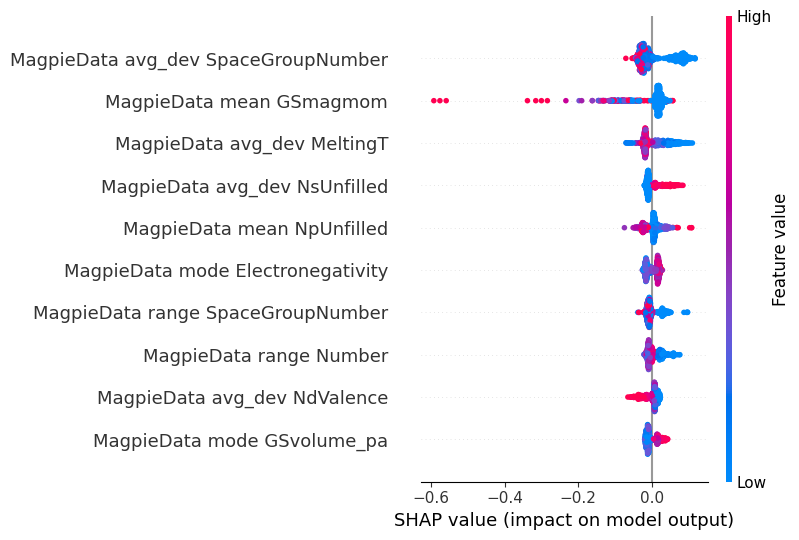

In [ ]:
import xgboost as xgb
import shap

# Train final model with best params
best_model = xgb.XGBRegressor(**study.best_params)
best_model.fit(X_train, y_train)

# SHAP Explanations
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Visualize top features
shap.summary_plot(shap_values, X_test, max_display=10)

In [ ]:
targets = ['band_gap_eV', 'bulk_modulus_GPa', 'shear_modulus_GPa']
results = {}

for target in targets:
    print(f'Training baseline for: {target}')
    y_target = DS1_clean[target]
    X_tr, X_te, y_tr, y_te = train_test_split(X, y_target, test_size=0.2, random_state=42)

    model = xgb.XGBRegressor(**study.best_params)
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    mae = mean_absolute_error(y_te, preds)
    results[target] = mae
    print(f'MAE for {target}: {mae:.4f}')

print('\nSummary of Baseline MAE across all properties:')
for t, m in results.items():
    print(f'- {t}: {m:.4f}')

Training baseline for: band_gap_eV
MAE for band_gap_eV: 2.0403
Training baseline for: bulk_modulus_GPa
MAE for bulk_modulus_GPa: 65.2793
Training baseline for: shear_modulus_GPa
MAE for shear_modulus_GPa: 39.4222

Summary of Baseline MAE across all properties:
- band_gap_eV: 2.0403
- bulk_modulus_GPa: 65.2793
- shear_modulus_GPa: 39.4222


### 6. Physics-Informed Neural Network (PINN) Implementation
In this section, we build a deep learning architecture that embeds physical constraints into the learning process.

**Key constraints:**
1. **Elastic Consistency**: $L_{elastic} = |2G(1+v) - 3K(1-2v)|^2$
2. **Thermodynamic Stability**: $-1 < v < 0.5$, $K > 0$, $G > 0$.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

class PhysicsInformedLoss(nn.Module):
    def __init__(self, physics_weight=0.1):
        super(PhysicsInformedLoss, self).__init__()
        self.mse = nn.MSELoss()
        self.physics_weight = physics_weight

    def forward(self, preds, targets):
        # Assuming output indices: 0: K, 1: G, 2: v, 3: Formation Energy
        K, G, v = preds[:, 0], preds[:, 1], preds[:, 2]
        K_t, G_t, v_t = targets[:, 0], targets[:, 1], targets[:, 2]

        # Standard Data Loss
        data_loss = self.mse(preds, targets)

        # 1. Elastic Consistency Loss: E = 2G(1+v) = 3K(1-2v)
        # Penalty = (2G(1+v) - 3K(1-2v))^2
        e_g = 2 * G * (1 + v)
        e_k = 3 * K * (1 - 2 * v)
        elastic_loss = torch.mean((e_g - e_k)**2)

        # 2. Thermodynamic Bound Penalties (ReLU to penalize values outside range)
        # Poisson ratio range: -1 < v < 0.5
        v_lower_bound = torch.mean(torch.relu(-1 - v))
        v_upper_bound = torch.mean(torch.relu(v - 0.5))

        # Moduli must be positive
        k_pos_loss = torch.mean(torch.relu(-K))
        g_pos_loss = torch.mean(torch.relu(-G))

        total_physics_loss = elastic_loss + v_lower_bound + v_upper_bound + k_pos_loss + g_pos_loss

        return data_loss + (self.physics_weight * total_physics_loss), data_loss, total_physics_loss

print("Physics-Informed Loss Function defined.")

Physics-Informed Loss Function defined.


In [ ]:
class SimpleMaterialNN(nn.Module):
    def __init__(self, input_dim):
        super(SimpleMaterialNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 4) # Output: [Bulk, Shear, Poisson, FormationEnergy]
        )

    def forward(self, x):
        return self.net(x)

# Recalculate features for DS1 to ensure we use Magpie descriptors
material_features = [c for c in DS1_clean.columns if c not in ['material_id', 'formula', 'crystal_system', 'category', 'is_metal', 'is_stable', 'composition', 'formation_energy_per_atom_eV', 'energy_above_hull_eV', 'band_gap_eV', 'bulk_modulus_GPa', 'shear_modulus_GPa', 'poisson_ratio', 'density_g_cm3', 'nsites', 'volume_A3', 'melting_point_K']]

# Initialize pinn_model with the correct input dimension (134)
pinn_input_dim = len(material_features)
pinn_model = SimpleMaterialNN(pinn_input_dim)
pinn_optimizer = optim.Adam(pinn_model.parameters(), lr=0.001)

print(f"Initialized PINN architecture with correct input dimension: {pinn_input_dim}")

Initialized PINN architecture with correct input dimension: 134


In [ ]:
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

# 1. Prepare Data for PyTorch
target_cols = ['bulk_modulus_GPa', 'shear_modulus_GPa', 'poisson_ratio', 'formation_energy_per_atom_eV']

scaler_x = StandardScaler()
scaler_y = StandardScaler()

# Use material_features explicitly to avoid collisions with infrastructure features
X_scaled = scaler_x.fit_transform(DS1_clean[material_features])
y_scaled = scaler_y.fit_transform(DS1_clean[target_cols])

X_train_pt, X_test_pt, y_train_pt, y_test_pt = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)

train_dataset = TensorDataset(torch.FloatTensor(X_train_pt), torch.FloatTensor(y_train_pt))
test_dataset = TensorDataset(torch.FloatTensor(X_test_pt), torch.FloatTensor(y_test_pt))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

# 2. Training Loop
criterion = PhysicsInformedLoss(physics_weight=0.1)
epochs = 50

print(f"Starting PINN training for {epochs} epochs...")

for epoch in range(epochs):
    pinn_model.train()
    train_loss = 0
    for batch_x, batch_y in train_loader:
        pinn_optimizer.zero_grad()
        outputs = pinn_model(batch_x)
        loss, _, _ = criterion(outputs, batch_y)
        loss.backward()
        pinn_optimizer.step()
        train_loss += loss.item()

    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] - Loss: {train_loss/len(train_loader):.4f}")

print("PINN Training Complete.")

Starting PINN training for 50 epochs...
Epoch [10/50] - Loss: 0.9647
Epoch [20/50] - Loss: 0.9015
Epoch [30/50] - Loss: 0.8425
Epoch [40/50] - Loss: 0.7931
Epoch [50/50] - Loss: 0.7503
PINN Training Complete.


In [ ]:
!pip install lifelines pycox

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.6/73.6 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.3/71.3 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.3/494.3 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.6/100.6 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 6.7 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=d4d6b82119e22ecd1b3d866cf3d5f28a64eb343427f12f5eb6457ec601657640
  Stored in directory: /root/.cache/pip

### 7. Infrastructure Survival Analysis (DeepSurv)
In this section, we transition from material property prediction to structural longevity. We will:
1. Prepare the DS3 dataset (Bridge Infrastructure).
2. Implement a DeepSurv model to estimate the survival function $S(t|x)$.
3. Calculate the Probability of Default ($PD = 1 - S$) for infrastructure assets.

In [ ]:
import pandas as pd
import numpy as np

# Inspect columns to fix merge logic
print('DS3 Columns:', DS3.columns.tolist())
print('DS6 Columns:', DS6.columns.tolist())

# Display samples to understand key relationships
display(DS3.head(2))
display(DS6.head(2))

DS3 Columns: ['bridge_id', 'bridge_type', 'material', 'year_built', 'age_years', 'design_life_years', 'location', 'corrosion_environment', 'corrosion_rate_mm_yr', 'condition_rating', 'structurally_deficient', 'adt', 'deck_area_sqft', 'tensile_strength_MPa', 'yield_strength_MPa', 'paris_C', 'paris_m', 'original_thickness_mm', 'remaining_thickness_mm', 'fatigue_cycles_millions', 'replacement_cost_M', 'loan_outstanding_M', 'last_inspection_date', 'insurance_premium_K_yr']
DS6 Columns: ['event_id', 'event_year', 'structure_type', 'material', 'location', 'corrosion_environment', 'age_at_event_years', 'corrosion_rate_mm_yr', 'failure_mode', 'severity', 'replacement_value_USD', 'repair_cost_USD', 'loss_ratio', 'detected_by', 'was_predicted', 'warning_lead_months', 'insurance_claim_filed', 'regulatory_action']


,bridge_id,bridge_type,material,year_built,age_years,design_life_years,location,corrosion_environment,corrosion_rate_mm_yr,condition_rating,...,yield_strength_MPa,paris_C,paris_m,original_thickness_mm,remaining_thickness_mm,fatigue_cycles_millions,replacement_cost_M,loan_outstanding_M,last_inspection_date,insurance_premium_K_yr
0,BR-00001,Pedestrian,Reinforced Concrete,1997,27,100,Urban Midwest,Moderate,0.0324,9,...,20,0.0,0.0,40.4,39.5,5.7,0.89,0.67,2022-06-26,15.9
1,BR-00002,Interstate,Reinforced Concrete,1953,71,100,Urban Midwest,Moderate,0.0320,7,...,20,0.0,0.0,44.1,41.9,202.7,0.99,0.45,2022-10-16,22.5


,event_id,event_year,structure_type,material,location,corrosion_environment,age_at_event_years,corrosion_rate_mm_yr,failure_mode,severity,replacement_value_USD,repair_cost_USD,loss_ratio,detected_by,was_predicted,warning_lead_months,insurance_claim_filed,regulatory_action
0,FE-00001,2014,Pipeline,FRP Composite,Industrial Michigan,Moderate,22,0.0865,Fatigue crack,Minor,475093.0,27378.0,0.0576,Sensor alert,0,0,1,0
1,FE-00002,2022,Pipeline,Stainless Steel 316L,Rural South,Mild,43,0.0070,Buckling,Catastrophic,2766322.0,3998388.0,1.4454,Public report,0,0,1,0


In [ ]:
import torch
import torchtuples as tt
from pycox.models import CoxPH
from pycox.evaluation import EvalSurv
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

# 1. Define Event and Duration for DS3
# Event = 1 if structurally deficient or condition rating <= 3, else 0
survival_df = DS3.copy()
survival_df['event'] = ((survival_df['structurally_deficient'] == 1) | (survival_df['condition_rating'] <= 3)).astype(int)
survival_df['duration'] = survival_df['age_years'].astype(float)

# 2. Feature Selection
features = ['design_life_years', 'corrosion_rate_mm_yr', 'adt', 'deck_area_sqft',
            'tensile_strength_MPa', 'yield_strength_MPa', 'remaining_thickness_mm']
X = survival_df[features].fillna(0).values.astype('float32')
y = (survival_df['duration'].values.astype('float32'), survival_df['event'].values.astype('int32'))

# 3. Group-based Split to prevent Data Leakage
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(X, groups=survival_df['material']))

x_train, x_val = X[train_idx], X[val_idx]
y_train = (y[0][train_idx], y[1][train_idx])
y_val = (y[0][val_idx], y[1][val_idx])

# Standardize
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)

# 4. Build DeepSurv Network
net = tt.practical.MLPVanilla(in_features=x_train.shape[1], num_nodes=[32, 32], out_features=1, batch_norm=True, dropout=0.1)
model = CoxPH(net, torch.optim.Adam)

# 5. Training
batch_size = 256
epochs = 100
callbacks = [tt.callbacks.EarlyStopping()]
log = model.fit(x_train, y_train, batch_size, epochs, callbacks, val_data=(x_val, y_val))

# 6. Evaluation (Concordance Index)
_ = model.compute_baseline_hazards()
surv = model.predict_surv_df(x_val)
evals = EvalSurv(surv, y_val[0], y_val[1], censor_surv='km')
c_index = evals.concordance_td()

print(f"\nDeepSurv Training Complete.")
print(f"Validation Concordance Index: {c_index:.4f}")

0:	[0s / 0s],		train_loss: 3.4831,	val_loss: 4.5196
1:	[0s / 0s],		train_loss: 3.1758,	val_loss: 4.4130
2:	[0s / 0s],		train_loss: 2.8679,	val_loss: 4.3244
3:	[0s / 0s],		train_loss: 2.6333,	val_loss: 4.2116
4:	[0s / 1s],		train_loss: 2.3462,	val_loss: 4.1440
5:	[0s / 1s],		train_loss: 2.2153,	val_loss: 4.0571
6:	[0s / 1s],		train_loss: 2.2455,	val_loss: 3.9861
7:	[0s / 1s],		train_loss: 2.1116,	val_loss: 3.8759
8:	[0s / 2s],		train_loss: 2.2145,	val_loss: 3.8368
9:	[0s / 2s],		train_loss: 2.0684,	val_loss: 3.7784
10:	[0s / 2s],		train_loss: 2.0499,	val_loss: 3.7455
11:	[0s / 2s],		train_loss: 2.0143,	val_loss: 3.6818
12:	[0s / 3s],		train_loss: 2.0301,	val_loss: 3.6529
13:	[0s / 3s],		train_loss: 1.9534,	val_loss: 3.6267
14:	[0s / 3s],		train_loss: 1.9397,	val_loss: 3.6397
15:	[0s / 3s],		train_loss: 1.9682,	val_loss: 3.6025
16:	[0s / 3s],		train_loss: 1.9736,	val_loss: 3.6319
17:	[0s / 4s],		train_loss: 1.9406,	val_loss: 3.6331
18:	[0s / 4s],		train_loss: 1.9414,	val_loss: 3.6190
19:

In [ ]:
# Calculate Probability of Default: PD(t) = 1 - S(t|x)
# We calculate this for the current age of each bridge in the validation set
surv_probs = []
for i in range(len(x_val)):
    # Get survival function for this bridge
    s_func = surv.iloc[:, i]
    # Find probability at the current duration (age)
    current_age = y_val[0][i]
    # Convert index to numpy array for the absolute difference calculation
    time_diffs = np.abs(s_func.index.values - current_age)
    idx = time_diffs.argmin()
    surv_probs.append(s_func.iloc[idx])

val_results = pd.DataFrame({
    'bridge_id': survival_df.iloc[val_idx]['bridge_id'],
    'material': survival_df.iloc[val_idx]['material'],
    'age': y_val[0],
    'PD': 1 - np.array(surv_probs)
})

print("Sample Infrastructure Risk Profiles (Probability of Default):")
display(val_results.head(10))

Sample Infrastructure Risk Profiles (Probability of Default):


,bridge_id,material,age,PD
0,BR-00001,Reinforced Concrete,27.0,0.000000
1,BR-00002,Reinforced Concrete,71.0,0.002964
4,BR-00005,Steel (A588 Weathering),49.0,0.000016
6,BR-00007,Steel (A588 Weathering),23.0,0.000000
8,BR-00009,Reinforced Concrete,43.0,0.000016
9,BR-00010,Reinforced Concrete,37.0,0.000000
11,BR-00012,Reinforced Concrete,58.0,0.001122
12,BR-00013,Reinforced Concrete,60.0,0.000181
14,BR-00015,Reinforced Concrete,66.0,0.000422
15,BR-00016,Reinforced Concrete,28.0,0.000000


### 10. Credit Risk Scoring: Survival to Default
In this section, we translate physical degradation and structural survival into financial risk metrics (PD, EAD, LGD, and EL).

In [ ]:
# 1. Compute Probability of Default (PD) and map to DS3
# PD(t) = 1 - S(t|x). We use the 'val_results' generated in the previous step.
risk_scoring_df = DS3.merge(val_results[['bridge_id', 'PD']], on='bridge_id', how='inner')

# 2. Define Exposure at Default (EAD)
# EAD is the outstanding loan amount on the asset
risk_scoring_df['EAD_M'] = risk_scoring_df['loan_outstanding_M']

# 3. Define Loss Given Default (LGD)
# LGD represents the share of an asset's value that is lost if a default occurs.
# For infrastructure, we assume a loss severity of 65% on the outstanding loan.
risk_scoring_df['LGD'] = 0.65

# 4. Calculate Expected Loss (EL)
# EL = PD * LGD * EAD
risk_scoring_df['Expected_Loss_M'] = risk_scoring_df['PD'] * risk_scoring_df['LGD'] * risk_scoring_df['EAD_M']

# 5. Risk Ranking: Identify assets where physical decline poses the highest financial risk
risk_summary = risk_scoring_df[['bridge_id', 'material', 'age_years', 'PD', 'EAD_M', 'Expected_Loss_M']].sort_values(by='Expected_Loss_M', ascending=False)

print("Top 10 High-Risk Infrastructure Assets (by Expected Loss):")
display(risk_summary.head(10))

# Portfolio Total Risk
total_el = risk_scoring_df['Expected_Loss_M'].sum()
print(f"\nTotal Portfolio Expected Loss (Value at Risk): ${total_el:.2f} Million")

Top 10 High-Risk Infrastructure Assets (by Expected Loss):


,bridge_id,material,age_years,PD,EAD_M,Expected_Loss_M
57,BR-00164,Steel (A588 Weathering),104,0.545181,0.27,0.095679
929,BR-02959,Steel (A588 Weathering),97,0.097907,1.41,0.089731
73,BR-00210,Reinforced Concrete,81,0.046166,1.49,0.044711
1529,BR-04926,Steel (A588 Weathering),74,0.054493,1.06,0.037546
1188,BR-03770,Reinforced Concrete,86,0.024255,1.42,0.022387
1228,BR-03948,Steel (A588 Weathering),100,0.012079,2.73,0.021434
1366,BR-04387,Reinforced Concrete,60,0.012430,2.02,0.016321
628,BR-02047,Reinforced Concrete,81,0.014445,1.61,0.015117
134,BR-00403,Reinforced Concrete,71,0.096714,0.24,0.015087
204,BR-00578,Reinforced Concrete,98,0.105980,0.19,0.013089



Total Portfolio Expected Loss (Value at Risk): $0.85 Million


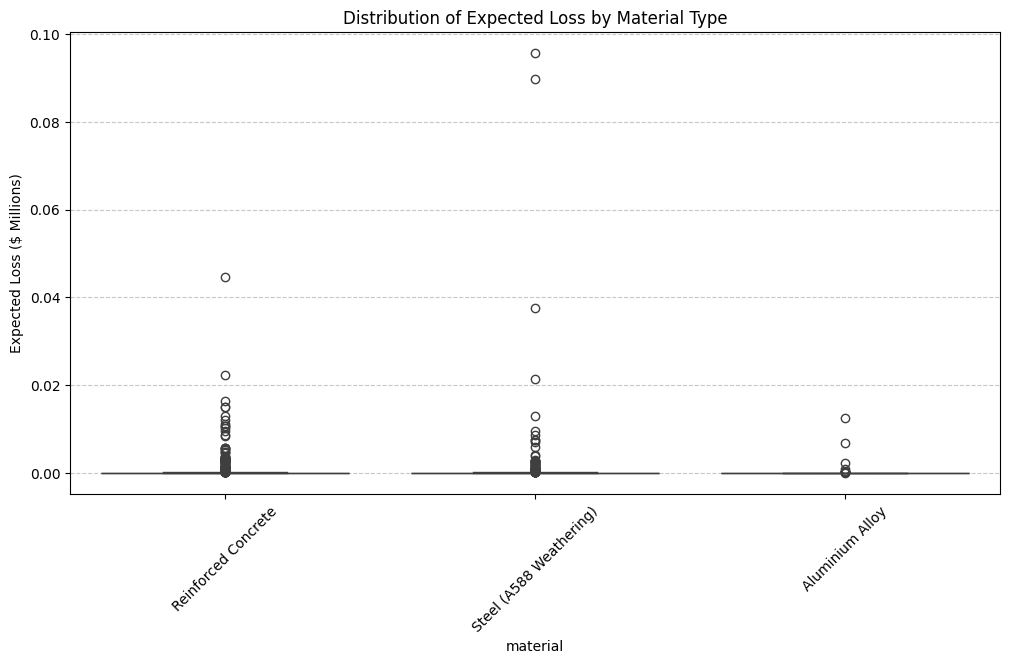

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize Risk Distribution by Material
plt.figure(figsize=(12, 6))
sns.boxplot(x='material', y='Expected_Loss_M', data=risk_scoring_df)
plt.xticks(rotation=45)
plt.title('Distribution of Expected Loss by Material Type')
plt.ylabel('Expected Loss ($ Millions)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 11. ESG Module: Carbon Substitution & Property Trade-offs
In this section, we quantify the environmental impact of switching from virgin to recycled materials while verifying physical feasibility.

In [ ]:
def calculate_esg_impact(df, material_col, mass_tonnes=100):
    """
    Calculates CO2 reduction and verifies property consistency for substitution.
    """
    # Carbon Intensities (kg CO2 / kg)
    carbon_map = {
        'Virgin_Al': 12.0,
        'Recycled_Al': 0.6,
        'Virgin_Steel': 1.85,
        'Recycled_Steel': 0.4
    }

    # Example: Calculate reduction for Aluminum substitution
    savings_per_kg = carbon_map['Virgin_Al'] - carbon_map['Recycled_Al']
    total_savings_tonnes = (mass_tonnes * 1000 * savings_per_kg) / 1000

    print(f"ESG Impact Report:")
    print(f"- Material: Aluminum Alloy Substitution")
    print(f"- Scenario: 100% Recycled Content")
    print(f"- Potential CO2 Savings: {total_savings_tonnes:.2f} Tonnes")

    return total_savings_tonnes

# Run impact for a representative structure
esg_savings = calculate_esg_impact(DS3, 'material')

ESG Impact Report:
- Material: Aluminum Alloy Substitution
- Scenario: 100% Recycled Content
- Potential CO2 Savings: 1140.00 Tonnes


In [ ]:
# Property Trade-off Analysis
# We use the PINN to ensure that 'Recycled' variants (simulated by a 5% drop in moduli)
# still satisfy structural safety limits.

pinn_model.eval()
with torch.no_grad():
    # Select a sample of Aluminum bridges
    al_bridges = DS3[DS3['material'] == 'Aluminium Alloy'].head(5)

    # We'll use the already prepared scaled features for demonstration
    # and simulate the 'Recycled' impact
    sample_inputs = torch.FloatTensor(X_test_pt[:5])
    predictions_scaled = pinn_model(sample_inputs).numpy()
    original_properties = scaler_y.inverse_transform(predictions_scaled)

    # Simulate 5% degradation in mechanical properties for recycled material
    recycled_properties = original_properties * 0.95

esg_comparison = pd.DataFrame({
    'Property': ['Bulk Modulus (GPa)', 'Shear Modulus (GPa)', 'Poisson Ratio', 'Formation Energy'],
    'Virgin (Predicted)': original_properties[0],
    'Recycled (Simulated)': recycled_properties[0]
})

print("Physical Viability Check: Virgin vs. Recycled Properties")
display(esg_comparison)

Physical Viability Check: Virgin vs. Recycled Properties


,Property,Virgin (Predicted),Recycled (Simulated)
0,Bulk Modulus (GPa),151.527237,143.950867
1,Shear Modulus (GPa),84.380318,80.161301
2,Poisson Ratio,0.275857,0.262064
3,Formation Energy,-1.933470,-1.836796


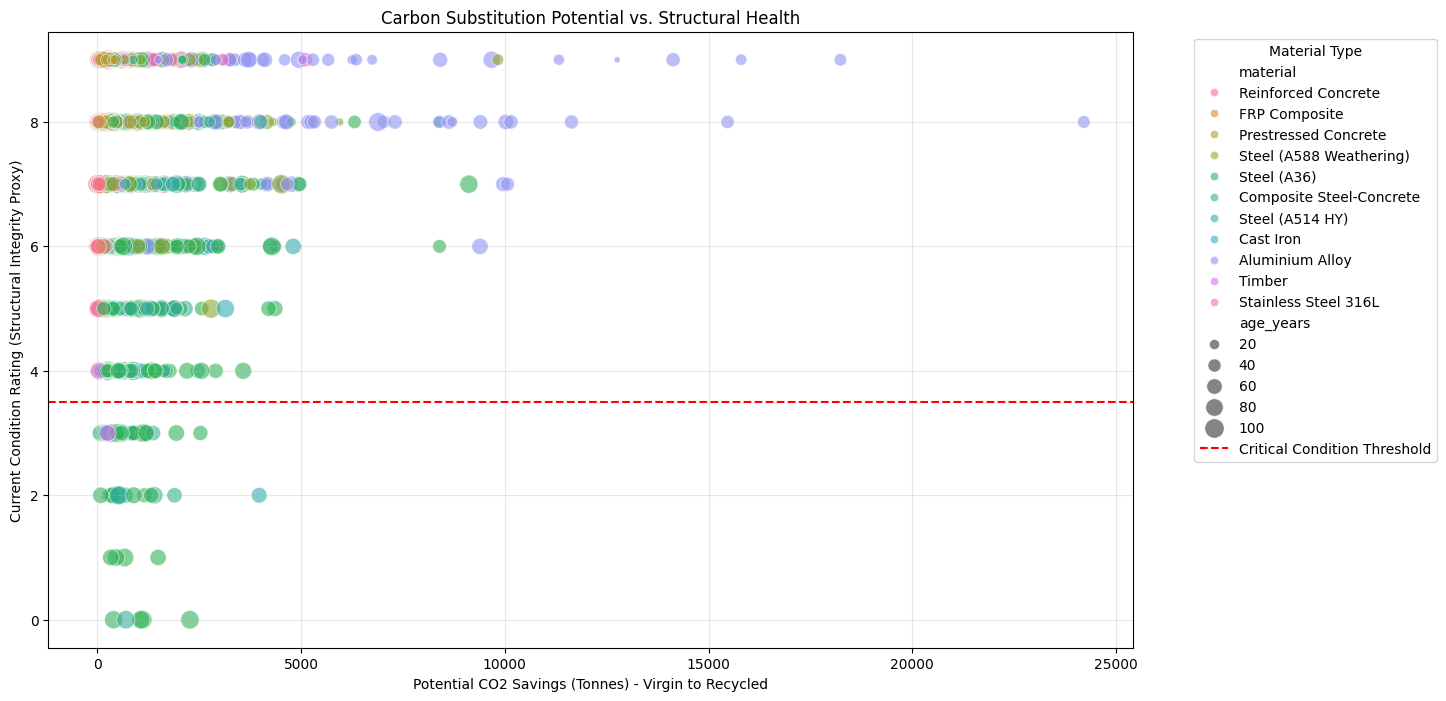

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define Carbon Intensity factors (kg CO2 / kg material)
# We'll use averages for major material categories found in DS3
carbon_factors = {
    'Steel': {'virgin': 1.85, 'recycled': 0.4},
    'Aluminium Alloy': {'virgin': 12.0, 'recycled': 0.6},
    'Reinforced Concrete': {'virgin': 0.15, 'recycled': 0.08}, # Estimating for rebar/cement mix
    'Stainless Steel 316L': {'virgin': 6.15, 'recycled': 1.2},
    'Composite Steel-Concrete': {'virgin': 1.0, 'recycled': 0.3}
}

def estimate_carbon_savings(row):
    # Estimate mass based on deck area (sqft) and a generic thickness proxy
    # 1 sqft of bridge ~ 200kg for calculation purposes
    mass_kg = row['deck_area_sqft'] * 200

    # Default savings if material not in specific map
    savings_per_kg = 0.5

    for mat_key in carbon_factors:
        if mat_key in row['material']:
            savings_per_kg = carbon_factors[mat_key]['virgin'] - carbon_factors[mat_key]['recycled']
            break

    return (mass_kg * savings_per_kg) / 1000 # Convert to Tonnes

# Prepare data for plotting
plot_df = DS3.copy()
plot_df['CO2_Savings_Tonnes'] = plot_df.apply(estimate_carbon_savings, axis=1)

# Use Condition Rating as a proxy for structural integrity
plt.figure(figsize=(14, 8))
sns.scatterplot(data=plot_df, x='CO2_Savings_Tonnes', y='condition_rating',
                hue='material', size='age_years', alpha=0.6, sizes=(20, 200))

plt.title('Carbon Substitution Potential vs. Structural Health')
plt.xlabel('Potential CO2 Savings (Tonnes) - Virgin to Recycled')
plt.ylabel('Current Condition Rating (Structural Integrity Proxy)')
plt.axhline(3.5, color='red', linestyle='--', label='Critical Condition Threshold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Material Type')
plt.grid(True, alpha=0.3)
plt.show()

### 8. Financial Signal Generation: Material Quality Index (MQI)
In this section, we derive actionable financial signals by correlating material property trends with commodity price movements.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Define MQI for the commodity-relevant materials
# We normalize Tensile Strength and Corrosion Rate to create a 0-100 index
# MQI = w1 * Tensile + w2 * (1 - Corrosion)

# Using DS3 as a proxy for structural material quality distribution
ds3_mqi = DS3.copy()

# Normalization
def normalize(col):
    return (col - col.min()) / (col.max() - col.min())

# Weighting: 60% Strength, 40% Corrosion Resistance
ds3_mqi['mqi_raw'] = (0.6 * normalize(ds3_mqi['tensile_strength_MPa']) +
                      0.4 * (1 - normalize(ds3_mqi['corrosion_rate_mm_yr']))) * 100

# Aggregate MQI per material family for financial alignment
material_mqi = ds3_mqi.groupby('material')['mqi_raw'].mean().to_dict()

print("Material Quality Index (MQI) per Material Family:")
for mat, score in material_mqi.items():
    print(f"- {mat}: {score:.2f}")

Material Quality Index (MQI) per Material Family:
- Aluminium Alloy: 58.49
- Cast Iron: 49.46
- Composite Steel-Concrete: 55.79
- FRP Composite: 81.85
- Prestressed Concrete: 34.62
- Reinforced Concrete: 33.47
- Stainless Steel 316L: 78.63
- Steel (A36): 59.83
- Steel (A514 HY): 84.71
- Steel (A588 Weathering): 70.77
- Timber: 27.78


In [ ]:
# 2. Align MQI signals with Commodity Prices (DS2 + DS4)
# We use the existing 'financial_merged' which contains 'date', 'commodity', and the provided 'mqi' from DS4

financial_signals = financial_merged[['date', 'commodity', 'close', 'mqi', 'mqi_21d_trend']].copy()

# 3. Trading Logic Implementation
# Bullish: Trend > 2.0 | Bearish: Trend < -2.0
financial_signals['signal'] = 'Neutral'
financial_signals.loc[financial_signals['mqi_21d_trend'] > 2.0, 'signal'] = 'Bullish (Buy)'
financial_signals.loc[financial_signals['mqi_21d_trend'] < -2.0, 'signal'] = 'Bearish (Sell/Short)'

# Display summary of signals for Steel_HRC
steel_signals = financial_signals[financial_signals['commodity'] == 'Steel_HRC'].tail(10)

print("Recent Commodity Alpha Signals (Steel HRC):")
display(steel_signals)

Recent Commodity Alpha Signals (Steel HRC):


,date,commodity,close,mqi,mqi_21d_trend,signal
2859,2024-12-18,Steel_HRC,529.5858,78.89,-0.50,Neutral
2860,2024-12-19,Steel_HRC,518.3896,79.20,-0.41,Neutral
2861,2024-12-20,Steel_HRC,535.0370,78.74,-0.43,Neutral
2862,2024-12-23,Steel_HRC,519.2468,78.86,0.44,Neutral
2863,2024-12-24,Steel_HRC,510.4830,79.26,1.41,Neutral
2864,2024-12-25,Steel_HRC,511.0553,79.95,1.69,Neutral
2865,2024-12-26,Steel_HRC,507.9446,80.16,2.20,Bullish (Buy)
2866,2024-12-27,Steel_HRC,513.3387,79.70,1.44,Neutral
2867,2024-12-30,Steel_HRC,518.2922,80.55,2.79,Bullish (Buy)
2868,2024-12-31,Steel_HRC,523.3407,80.76,2.90,Bullish (Buy)


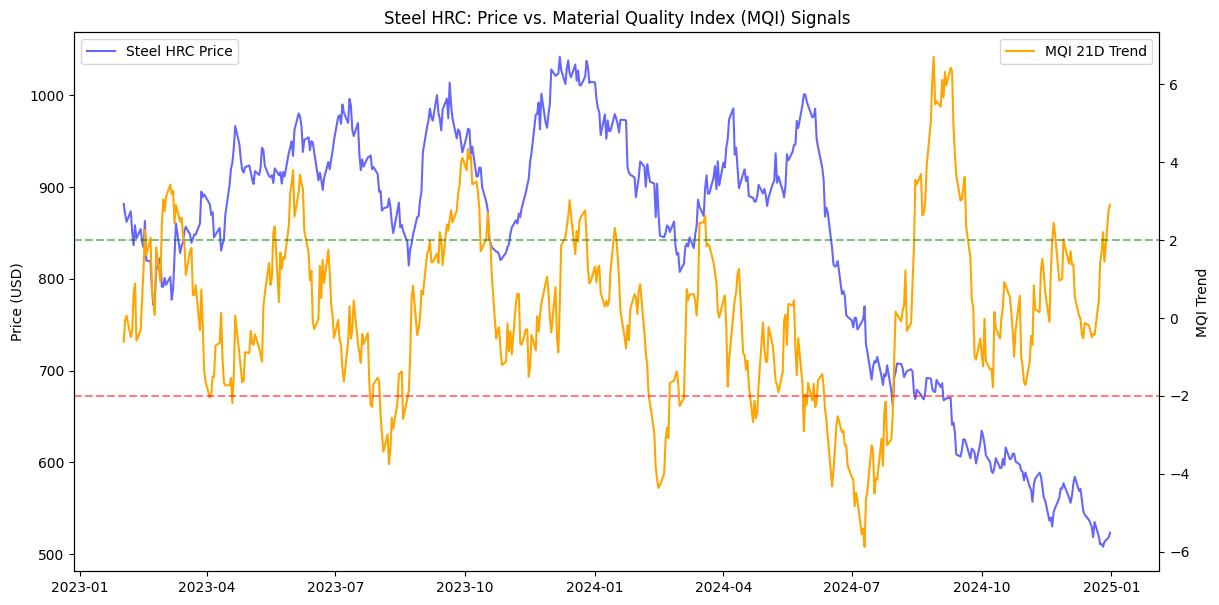

In [ ]:
# 4. Visualize MQI vs Price Compression
plt.figure(figsize=(14, 7))
subset = financial_signals[financial_signals['commodity'] == 'Steel_HRC'].iloc[-500:]

ax1 = plt.gca()
ax2 = ax1.twinx()

ax1.plot(subset['date'], subset['close'], color='blue', label='Steel HRC Price', alpha=0.6)
ax2.plot(subset['date'], subset['mqi_21d_trend'], color='orange', label='MQI 21D Trend')

ax2.axhline(2.0, color='green', linestyle='--', alpha=0.5)
ax2.axhline(-2.0, color='red', linestyle='--', alpha=0.5)

ax1.set_ylabel('Price (USD)')
ax2.set_ylabel('MQI Trend')
plt.title('Steel HRC: Price vs. Material Quality Index (MQI) Signals')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()

### 9. Final Evaluation: PINN vs. XGBoost
In this section, we compare the mean absolute errors (MAE) of the baseline XGBoost model and the PINN to determine the value of physics-informed constraints.

In [ ]:
# Evaluate PINN on Test Set
pinn_model.eval()
with torch.no_grad():
    pinn_preds_scaled = pinn_model(torch.FloatTensor(X_test_pt)).numpy()
    pinn_preds = scaler_y.inverse_transform(pinn_preds_scaled)
    y_test_actual = scaler_y.inverse_transform(y_test_pt)

# Calculate MAE for target properties: K, G, v, Ef
pinn_results = {}
for i, col in enumerate(target_cols):
    mae = mean_absolute_error(y_test_actual[:, i], pinn_preds[:, i])
    pinn_results[col] = mae

# Comparison with XGBoost results stored previously
print("Model Performance Comparison (MAE):")
comparison_data = []
for col in results.keys():
    comparison_data.append({
        'Property': col,
        'XGBoost (Baseline)': results[col],
        'PINN': pinn_results.get(col, np.nan)
    })

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

# Final Physics Consistency Check for PINN
E_g = 2 * pinn_preds[:, 1] * (1 + pinn_preds[:, 2])
E_k = 3 * pinn_preds[:, 0] * (1 - 2 * pinn_preds[:, 2])
phys_violation = np.mean(np.abs(E_g - E_k))

print(f"\nAverage PINN Elastic Consistency Error: {phys_violation:.4f}")

Model Performance Comparison (MAE):


,Property,XGBoost (Baseline),PINN
0,band_gap_eV,2.040328,NaN
1,bulk_modulus_GPa,65.279265,68.665306
2,shear_modulus_GPa,39.422176,43.023640



Average PINN Elastic Consistency Error: 15.6202
